## artificial neural network classifier 
After preprocessing, every match becomes a numerical vector.

Conceptually, the network receives inputs such as:

Ranking difference
Points difference
Previous win-rate difference
Recent-form difference
Surface win-rate difference
Head-to-head information
Tournament surface
Tournament round

The network contains:

Input layer → Hidden layer or layers → Output

Each hidden neuron calculates a weighted combination of its inputs, adds a bias and applies an activation function. During training, the weights are repeatedly adjusted to reduce classification error.

The goal of this notebook is to use an Artificial Neural Network
to predict whether Player 1 wins the match.

The network receives the numerical pre-match features created in the
previous notebooks. The output is a probability between 0 and 1.

A value close to 1 means that the network expects Player 1 to win,
while a value close to 0 means that it expects Player 2 to win.

In [1]:
from pathlib import Path 

import numpy as np 
import pandas as pd 
import tensorflow as tf

import matplotlib.pyplot as plt 

from sklearn.preprocessing import StandardScaler 

import sys
from pathlib import Path
PROJECT_ROOT = Path("..").resolve()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))
    
from src.preprocessing import (
    fit_preprocessor,
    transform_data,
    categorical_features,
    numeric_features
)

from sklearn.metrics import (
    accuracy_score, 
    balanced_accuracy_score, 
    precision_score, 
    recall_score, 
    f1_score,
    roc_auc_score,
    log_loss,
    classification_report,
    ConfusionMatrixDisplay
)

from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Activation 
from tensorflow.keras import Input 
from tensorflow.keras import optimizers

In [2]:
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
PROCESSED_DATA_DIR = Path("../data/processed")

input_file = (
    PROCESSED_DATA_DIR / "feature_split_matches.csv"
)

matches = pd.read_csv(
    input_file, parse_dates = ["Date"]
)

matches = matches.sort_values(
    by=["Date", "MatchID"]
).reset_index(drop=True)

print("Dataset shape:", matches.shape)
print(matches["DataSplit"].value_counts())


Dataset shape: (26536, 53)
DataSplit
Training      18810
Test           5119
Validation     2607
Name: count, dtype: int64


In [4]:
## create copies of the sets 
train_data = matches.loc[
    matches["DataSplit"] == "Training"
].copy()

validation_data = matches.loc[
    matches["DataSplit"] == "Validation"
].copy()

test_data = matches.loc[
    matches["DataSplit"] == "Test"
].copy()

## check the periods
print(
    "Training:", 
    train_data["Date"].min(),
    "-",
    train_data["Date"].max()
)

print(
    "Validating:", 
    validation_data["Date"].min(),
    "-",
    validation_data["Date"].max()
)

print(
    "Testing:", 
    test_data["Date"].min(),
    "-",
    test_data["Date"].max()
)


Training: 2015-01-05 00:00:00 - 2022-11-20 00:00:00
Validating: 2023-01-01 00:00:00 - 2023-12-31 00:00:00
Testing: 2024-01-01 00:00:00 - 2025-11-16 00:00:00


In [5]:
assert(
    train_data["Date"].max() < validation_data["Date"].min()
)

assert(
    validation_data["Date"].max() < test_data["Date"].min()
)

print("Chronological order is maintained.")

Chronological order is maintained.


In [6]:
# The feature lists are imported from preprocessing.py.
# This ensures that all prediction models use
# exactly the same starting feature set.

print(
    "Numerical features:",
    len(numeric_features)
)

print(
    "Categorical features:",
    len(categorical_features)
)

print(
    "Raw features:",
    len(numeric_features) + len(categorical_features)
)


Numerical features: 30
Categorical features: 5
Raw features: 35


In [7]:
## create input and outputs
(
    numeric_medians,
    categorical_modes,
    one_hot_encoder
) = fit_preprocessor(
    train_data
)

X_train = transform_data(
    train_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

X_validation = transform_data(
    validation_data,
    numeric_medians,
    categorical_modes,
    one_hot_encoder
)

# Target:
# 1 = Player 1 wins
# 0 = Player 2 wins
y_train = train_data["Player1Won"].to_numpy()
y_validation = validation_data["Player1Won"].to_numpy()


In [8]:
# After preprocessing we expect:
# 30 numerical features
# + 20 one-hot encoded categorical features
# = 50 final model features

print("Training X:", X_train.shape)
print("Training y:", y_train.shape)

print("Validating X:", X_validation.shape)
print("Validating y:", y_validation.shape)

assert X_train.shape[1] == 50
assert X_validation.shape[1] == 50

assert X_train.isna().sum().sum() == 0
assert X_validation.isna().sum().sum() == 0

print(
    "ANN preprocessing check passed."
)

Training X: (18810, 50)
Training y: (18810,)
Validating X: (2607, 50)
Validating y: (2607,)
ANN preprocessing check passed.


The ANN is trained on standardized numerical inputs.

`fit_transform` is used only on the training set.  
For validation I use only `transform`, so the validation distribution is not used to fit the scaler.

In [9]:
# standardize the input 
# One-hot encoded features are already binary (0/1).
# Standardize only the original numerical features.

normalizer = StandardScaler()

X_train[numeric_features] = normalizer.fit_transform(X_train[numeric_features])
X_validation[numeric_features] = normalizer.transform(X_validation[numeric_features])

# Numerical training variables should now
# have mean approximately 0 and standard deviation approximately 1.
X_train[numeric_features].describe().T.head(10)


,count,mean,std,min,25%,50%,75%,max
Player1Rank,18810.0,6.648353e-17,1.000027,-0.793058,-0.538951,-0.229603,0.190227,22.905215
Player2Rank,18810.0,7.101650e-17,1.000027,-0.786692,-0.525388,-0.220532,0.182312,19.028912
Player1Points,18810.0,1.510989e-18,1.000027,-0.830961,-0.491406,-0.329513,0.040528,8.077883
Player2Points,18810.0,-4.381869e-17,1.000027,-0.832648,-0.486083,-0.320054,0.035109,8.188260
Player1MatchesBefore,18810.0,0.000000e+00,1.000027,-1.139764,-0.818762,-0.276378,0.598076,3.841308
Player2MatchesBefore,18810.0,9.670332e-17,1.000027,-1.125410,-0.816726,-0.287553,0.572353,3.846609
ExperienceDifference,18810.0,3.777473e-18,1.000027,-3.920863,-0.482052,0.001086,0.484225,3.979876
Player1WinRateBefore,18810.0,2.750001e-16,1.000027,-3.317998,-0.637339,-0.106858,0.635232,3.222076
Player2WinRateBefore,18810.0,-6.882556e-16,1.000027,-3.430939,-0.623094,-0.099114,0.627179,3.245129
WinRateDifference,18810.0,-4.532968e-18,1.000027,-3.881126,-0.654353,-0.006439,0.652866,4.210699


In [10]:
# Convert the final DataFrames to NumPy arrays
# before giving them to TensorFlow.

X_train = X_train.to_numpy(dtype=np.float32)
X_validation = X_validation.to_numpy(dtype=np.float32)

print("Final ANN Training matrix:", X_train.shape)
print("Final ANN Validation matrix:", X_validation.shape)

Final ANN Training matrix: (18810, 50)
Final ANN Validation matrix: (2607, 50)


In [11]:
# create first neural network 

num_instances, num_features = X_train.shape 

print("Number of training matches:", num_instances)
print("Number of input features:", num_features)

Number of training matches: 18810
Number of input features: 50


The first ANN is intentionally small:

26 inputs → 16 ReLU neurons → 1 sigmoid output.

This is a binary classification problem, so the sigmoid output represents the estimated probability that Player 1 wins.  
The predictive ANN lesson uses sigmoid with `binary_crossentropy` for binary classification.

In [12]:
#initialize network 
model = Sequential()

#specify num of input features
model.add( Input(shape = (num_features, )))

#hidden layer
model.add( Dense(16))
model.add( Activation("relu"))

#output layer 
model.add( Dense(1))
model.add(Activation("sigmoid"))

In [13]:
model.compile(
    optimizer = optimizers.Adam(
        learning_rate=0.001),
        loss="binary_crossentropy", 
        metrics=["accuracy"]
)

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 16)             │           816 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation (Activation)         │ (None, 16)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 1)              │            17 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ activation_1 (Activation)       │ (None, 1)              │             0 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 833 (3.25 KB)

 Trainable params: 833 (3.25 KB)

 Non-trainable params: 0 (0.00 B)

In [15]:
hist = model.fit(
    x = X_train, 
    y = y_train, 
    epochs = 50,
    validation_data = (
        X_validation, 
        y_validation
    ), 
    verbose=1
)

Epoch 1/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 3s 3ms/step - accuracy: 0.6416 - loss: 0.6263 - val_accuracy: 0.6364 - val_loss: 0.6259
Epoch 2/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6615 - loss: 0.6100 - val_accuracy: 0.6356 - val_loss: 0.6253
Epoch 3/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - accuracy: 0.6653 - loss: 0.6067 - val_accuracy: 0.6344 - val_loss: 0.6272
Epoch 4/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6683 - loss: 0.6048 - val_accuracy: 0.6279 - val_loss: 0.6281
Epoch 5/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6692 - loss: 0.6037 - val_accuracy: 0.6298 - val_loss: 0.6288
Epoch 6/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6699 - loss: 0.6029 - val_accuracy: 0.6298 - val_loss: 0.6289
Epoch 7/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6700 - loss: 0.6021 - val_accuracy: 0.6306 - val_loss: 0.6290
Epoch 8/50
588/588 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - accuracy: 0.6704 - loss: 0.6015 - val_accuracy: 0.

In [16]:
hist.history.keys()

dict_keys(['accuracy', 'loss', 'val_accuracy', 'val_loss'])

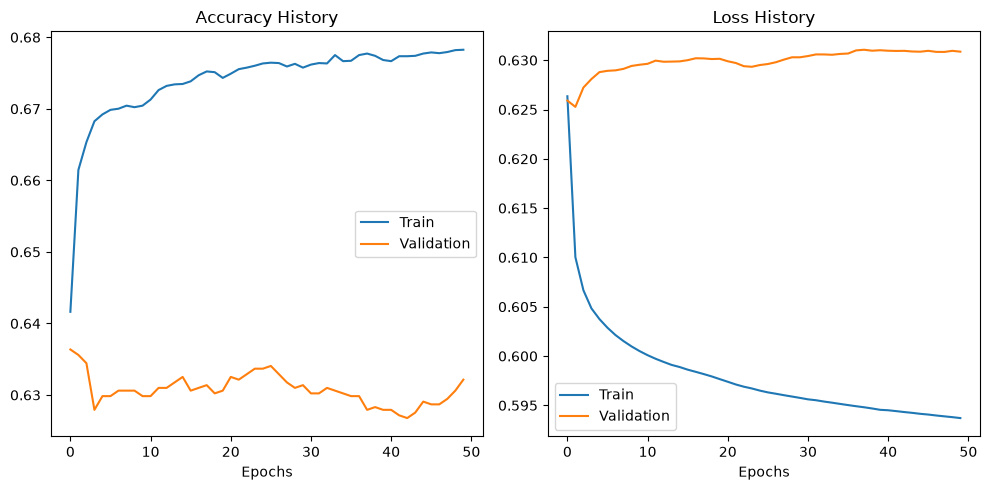

In [17]:
# plot training and validation accuracy 

%matplotlib inline 

fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 5)
)

axes[0].plot(hist.history["accuracy"], label="Train")
axes[0].plot(hist.history["val_accuracy"], label="Validation")

axes[0].set_title("Accuracy History")
axes[0].set_xlabel("Epochs")
axes[0].legend()

axes[1].plot(hist.history["loss"], label="Train")
axes[1].plot(hist.history["val_loss"], label="Validation")

axes[1].set_title("Loss History")
axes[1].set_xlabel("Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()


In [18]:
validation_loss, validation_accuracy = (
    model.evaluate(
        X_validation, 
        y_validation, 
        verbose=0
    )
)

print("Validation loss:", validation_loss)
print("Validation accuracy:", validation_accuracy)

Validation loss: 0.630864143371582
Validation accuracy: 0.6321442127227783


In [19]:
validation_probabilities = model.predict(
    X_validation, 
    verbose=0
)

validation_probabilities = (
    validation_probabilities.reshape(-1)
)

In [20]:
validation_predictions = (
    validation_probabilities >= 0.5
).astype(int)

In [21]:
prediction_example = pd.DataFrame(
    {
        "ProbabilityPlayer1Wins": validation_probabilities[:10],
        "PredictedClass": validation_predictions[:10],
        "TrueClass": y_validation[:10]
    }
)

prediction_example

,ProbabilityPlayer1Wins,PredictedClass,TrueClass
0,0.574328,1,0
1,0.491520,0,0
2,0.397282,0,0
3,0.615242,1,1
4,0.608363,1,0
5,0.666107,1,0
6,0.810983,1,0
7,0.550605,1,1
8,0.319628,0,0
9,0.547451,1,0


In [22]:
initial_results = pd.DataFrame(
    {
        "Model": ["Initial ANN"],
        "Accuracy": [
            accuracy_score(y_validation, validation_predictions)
        ], 
        "BalancedAccuracy": [
            balanced_accuracy_score(y_validation, validation_predictions)
        ], 
        "Precision": [
            precision_score(y_validation, validation_predictions, zero_division=0)
        ], 
        "Recall": [
            recall_score(y_validation, validation_predictions, zero_division=0)
        ], 
        "F1": [
            f1_score(y_validation, validation_predictions, zero_division=0)
        ], 
        "ROC_AUC": [
            roc_auc_score(y_validation, validation_probabilities)
        ], 
        "LogLoss": [
            log_loss(y_validation, validation_probabilities)
        ]
    }
)

initial_results

,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,LogLoss
0,Initial ANN,0.632144,0.633201,0.604322,0.65456,0.628439,0.6916,0.630864


In [23]:
print("Classification Report")

print(
    classification_report(
        y_validation, 
        validation_predictions, 
        target_names=[
            "Player 2 wins", 
            "Player 1 wins"
        ], 
        zero_division=0
    )
)

Classification Report
               precision    recall  f1-score   support

Player 2 wins       0.66      0.61      0.64      1368
Player 1 wins       0.60      0.65      0.63      1239

     accuracy                           0.63      2607
    macro avg       0.63      0.63      0.63      2607
 weighted avg       0.63      0.63      0.63      2607



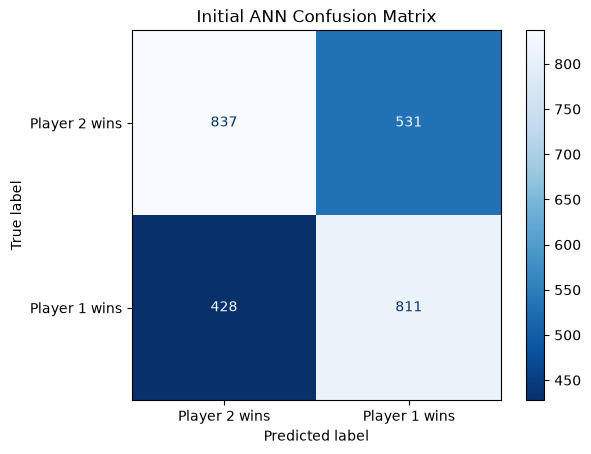

In [24]:
ConfusionMatrixDisplay.from_predictions(
    y_validation,
    validation_predictions,
    display_labels=[
        "Player 2 wins",
        "Player 1 wins"
    ],
    values_format="d",
    cmap="Blues_r"
)

plt.title("Initial ANN Confusion Matrix")
plt.show()

The project requires parameter tuning. I keep the search small and manual, like the experiments in the lessons.

I vary:
- hidden-layer size
- number of hidden layers
- activation
- learning rate
- number of epochs

In [25]:
def build_model(
    hidden_layers, 
    hidden_activation, 
    learning_rate
):
    #initialize network 
    current_model = Sequential()
    
    #input 
    current_model.add(Input(shape=(num_features,)))
    
    #hidden layer 
    for number_of_neurons in hidden_layers: 
        
        current_model.add(Dense(number_of_neurons))
        current_model.add(Activation(hidden_activation))
        
    #output 
    current_model.add(Dense(1))
    current_model.add(Activation("sigmoid"))
    
    #finalize the network 
    current_model.compile(
        optimizer=optimizers.Adam(
            learning_rate=learning_rate
        ), 
        loss="binary_crossentropy",
        metrics=["accuracy"]
    )
    
    return current_model

In [26]:
configurations = [
    {
        "name" : "ANN 8 sigmoid",
        "hidden_layers": [8], 
        "activation": "sigmoid", 
        "learning_rate": 0.01, 
        "epochs": 50
    }, 
    
    {
        "name": "ANN 16 relu",
        "hidden_layers": [16], 
        "activation": "relu", 
        "learning_rate": 0.001, 
        "epochs": 50
    },
    
    {
        "name": "ANN 32 relu", 
        "hidden_layers": [32], 
        "activation": "relu", 
        "learning_rate": 0.001, 
        "epochs": 50
    }, 
    
    {
        "name": "ANN 32-16 relu", 
        "hidden_layers": [32, 16], 
        "activation": "relu", 
        "learning_rate": 0.001, 
        "epochs": 50
    }, 
    
    {
        "name": "ANN 32-16 slow", 
        "hidden_layers": [32, 16], 
        "activation": "relu",
        "learning_rate": 0.0005, 
        "epochs": 100
    }
    
]

In [27]:
tuning_results = []

trained_models = {}
training_histories = {}

for configuration in configurations: 
    
    print("\nTraining:", configuration["name"])
    
    #reset the random seed
    np.random.seed(42)
    tf.random.set_seed(42)
    
    current_model = build_model(
        hidden_layers=(
            configuration["hidden_layers"]
        ), 
        hidden_activation=(
            configuration["activation"]
        ), 
        learning_rate=(
            configuration["learning_rate"]
        )
    )
    
    current_history = current_model.fit(
        x = X_train, 
        y = y_train, 
        epochs= configuration["epochs"],
        validation_data=(
            X_validation, 
            y_validation
        ),
        verbose=0
    )

    current_probabilities = (
        current_model.predict(
            X_validation, 
            verbose=0
        ).reshape(-1)
    )

    current_predictions = (
        current_probabilities >= 0.5
    ).astype(int)

    current_accuracy = accuracy_score(
        y_validation, 
        current_predictions
    )

    current_balanced_accuracy = (
        balanced_accuracy_score(
            y_validation, 
            current_predictions
        )
    )

    current_precision = precision_score(
        y_validation, 
        current_predictions, 
        zero_division=0
    )

    current_recall = recall_score(
        y_validation, 
        current_predictions, 
        zero_division=0
    )

    current_f1 = f1_score(
        y_validation, 
        current_predictions, 
        zero_division=0
    )

    current_roc_auc = roc_auc_score(
        y_validation, 
        current_probabilities
    )

    current_log_loss = log_loss(
        y_validation, 
        current_probabilities
    )

    tuning_results.append(
        {
            "Model": configuration["name"], 
            "HiddenLayers": str( configuration["hidden_layers"]), 
            "Activation": configuration["activation"], 
            "LearningRate": configuration["learning_rate"], 
            "Epochs": configuration["epochs"], 
            "Accuracy": current_accuracy, 
            "BalancedAccuracy": current_balanced_accuracy, 
            "Precision": current_precision, 
            "Recall": current_recall, 
            "F1": current_f1, 
            "ROC_AUC": current_roc_auc, 
            "LogLoss": current_log_loss
        }
    )

    trained_models[
        configuration["name"]
    ] = current_model

    training_histories[
        configuration["name"]
    ]= current_history

    print("Validation accuracy:", round(current_accuracy, 4))


Training: ANN 8 sigmoid
Validation accuracy: 0.6245

Training: ANN 16 relu
Validation accuracy: 0.6387

Training: ANN 32 relu
Validation accuracy: 0.6241

Training: ANN 32-16 relu
Validation accuracy: 0.6229

Training: ANN 32-16 slow
Validation accuracy: 0.6084


In [28]:
tuning_results = pd.DataFrame(tuning_results)

tuning_results = tuning_results.sort_values(
    by=[
        "Accuracy", "ROC_AUC"
    ], 
    ascending=[False, False]
).reset_index(drop=True)

tuning_results 

,Model,HiddenLayers,Activation,LearningRate,Epochs,Accuracy,BalancedAccuracy,Precision,Recall,F1,ROC_AUC,LogLoss
0,ANN 16 relu,[16],relu,0.0010,50,0.638665,0.640023,0.609433,0.667474,0.637134,0.692991,0.629957
1,ANN 8 sigmoid,[8],sigmoid,0.0100,50,0.624473,0.626919,0.591808,0.676352,0.631262,0.688851,0.634657
2,ANN 32 relu,[32],relu,0.0010,50,0.624089,0.625221,0.596140,0.648103,0.621036,0.681647,0.639042
3,ANN 32-16 relu,"[32, 16]",relu,0.0010,50,0.622938,0.623592,0.596823,0.636804,0.616166,0.676770,0.658149
4,ANN 32-16 slow,"[32, 16]",relu,0.0005,100,0.608362,0.609703,0.580147,0.636804,0.607157,0.665618,0.674440


In [29]:
best_model_name = (tuning_results.iloc[0]["Model"])
best_model = trained_models[best_model_name]
best_history = training_histories[best_model_name]

print("Selected model:", best_model_name)

Selected model: ANN 16 relu


In [30]:
best_validation_probabilities = (
    best_model.predict(
        X_validation, 
        verbose=0
    ).reshape(-1)
)

best_validation_predictions = (
    best_validation_probabilities >= 0.5 
).astype(int)

print(
    classification_report(
        y_validation, 
        best_validation_predictions, 
        target_names = [
            "Player 2 wins", 
            "Player 1 wins"
        ], 
        zero_division = 0
    )
)

               precision    recall  f1-score   support

Player 2 wins       0.67      0.61      0.64      1368
Player 1 wins       0.61      0.67      0.64      1239

     accuracy                           0.64      2607
    macro avg       0.64      0.64      0.64      2607
 weighted avg       0.64      0.64      0.64      2607



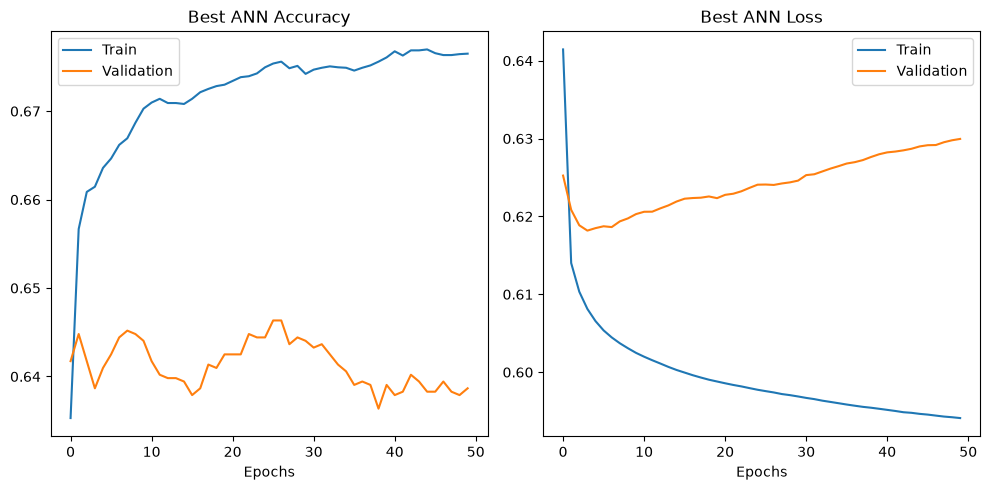

In [31]:
fig, axes = plt.subplots(
    nrows=1, 
    ncols=2, 
    figsize=(10, 5)
)

axes[0].plot(best_history.history["accuracy"], label="Train")
axes[0].plot(best_history.history["val_accuracy"], label="Validation")

axes[0].set_title("Best ANN Accuracy")
axes[0].set_xlabel("Epochs")
axes[0].legend()

axes[1].plot(best_history.history["loss"], label="Train")
axes[1].plot(best_history.history["val_loss"], label="Validation")

axes[1].set_title("Best ANN Loss")
axes[1].set_xlabel("Epochs")
axes[1].legend()

plt.tight_layout()
plt.show()

In [32]:
## compare with the baseline 
baseline_file = (PROCESSED_DATA_DIR / "validation_baseline.csv")
baseline_results = pd.read_csv(baseline_file)

best_ann_result = tuning_results.loc[
    [0], 
    [
        "Model",
        "Accuracy",
        "BalancedAccuracy",
        "Precision",
        "Recall",
        "F1"  
    ]
].copy()

# combine baseline results and ANN result
comparison_results = pd.concat(
    [
        baseline_results[
            [
                "Model",
                "Accuracy",
                "BalancedAccuracy",
                "Precision",
                "Recall",
                "F1"
            ]
        ],
        best_ann_result
    ],
    ignore_index=True
)

comparison_results = (
    comparison_results
    .sort_values(
        by="Accuracy", ascending=False
    ).reset_index(drop=True)
)

comparison_results


,Model,Accuracy,BalancedAccuracy,Precision,Recall,F1
0,Better-ranked player,0.640199,0.640648,0.614973,0.649718,0.631868
1,ANN 16 relu,0.638665,0.640023,0.609433,0.667474,0.637134
2,More ranking points,0.626007,0.626592,0.600152,0.638418,0.618694
3,Higher previous win rate,0.607979,0.608424,0.582635,0.617433,0.599530
4,Better recent win rate,0.549674,0.557169,0.519219,0.708636,0.599317
5,Majority class,0.524741,0.500000,0.000000,0.000000,0.000000


In [33]:
# create an analysis table
ann_validation_analysis = (
    validation_data [
        [   
            "MatchID",
            "Date",
            "Tournament",
            "Surface",
            "Round",
            "Player1",
            "Player2",
            "Player1Rank",
            "Player2Rank",
            "RankDifference",
            "WinRateDifference",
            "Recent5WinRateDifference",
            "SurfaceWinRateDifference",
            "Player1Won"
        ]
    ].copy()
)

In [34]:
# add the ann results
ann_validation_analysis[
    "ANNProbability"
] = best_validation_probabilities

ann_validation_analysis[
    "ANNPrediction"
] = best_validation_predictions

ann_validation_analysis[
    "Correct"
] = (
    ann_validation_analysis[
        "ANNPrediction"
    ] == ann_validation_analysis[
        "Player1Won"
    ]
)

#calculate prediction confidence
ann_validation_analysis[
    "Confidence"
] = np.maximum(
    ann_validation_analysis[
        "ANNProbability"
    ],
    1 - ann_validation_analysis["ANNProbability"]
)

#display the ten most confident errors 
most_confident_errors = (
    ann_validation_analysis.loc[
        ann_validation_analysis[
            "Correct"
        ] == False
    ].sort_values(
        by="Confidence", ascending=False
    )
)

most_confident_errors.head(10)


,MatchID,Date,Tournament,Surface,Round,Player1,Player2,Player1Rank,Player2Rank,RankDifference,WinRateDifference,Recent5WinRateDifference,SurfaceWinRateDifference,Player1Won,ANNProbability,ANNPrediction,Correct,Confidence
19137,19137,2023-02-14,Delray Beach Open,Hard,1st Round,Sock J.,Pecotic M.,143.0,784.0,641.0,0.073991,-0.1,0.087500,0,0.968280,1,False,0.968280
18984,18984,2023-01-18,Australian Open,Hard,2nd Round,Nadal R.,Mcdonald M.,2.0,65.0,63.0,0.387710,0.0,0.346032,0,0.920149,1,False,0.920149
20831,20831,2023-08-28,US Open,Hard,1st Round,Carballes Baena R.,Rune H.,63.0,4.0,-59.0,-0.159546,-0.2,-0.250169,1,0.080719,0,False,0.919281
20350,20350,2023-07-05,Wimbledon,Grass,1st Round,Korda S.,Vesely J.,25.0,528.0,503.0,0.124400,0.2,0.013889,0,0.910560,1,False,0.910560
19001,19001,2023-01-19,Australian Open,Hard,2nd Round,Zverev A.,Mmoh M.,13.0,107.0,94.0,0.374317,0.8,0.335272,0,0.903260,1,False,0.903260
19935,19935,2023-05-15,Internazionali BNL d'Italia,Clay,3rd Round,Alcaraz C.,Marozsan F.,2.0,135.0,133.0,0.031690,0.0,0.073529,0,0.896555,1,False,0.896555
21209,21209,2023-10-19,Japan Open Tennis Championships,Hard,2nd Round,Mochizuki S.,Fritz T.,215.0,10.0,-205.0,-0.392358,-0.4,-0.372372,1,0.105397,0,False,0.894603
20900,20900,2023-08-30,US Open,Hard,2nd Round,Tsitsipas S.,Stricker D.,7.0,128.0,121.0,0.149212,0.0,0.076877,0,0.892222,1,False,0.892222
21323,21323,2023-10-31,BNP Paribas Masters,Hard,2nd Round,Safiullin R.,Alcaraz C.,45.0,2.0,-43.0,-0.290055,-0.2,-0.294444,1,0.113627,0,False,0.886373
20052,20052,2023-05-30,French Open,Clay,1st Round,Baez S.,Monfils G.,42.0,394.0,352.0,-0.151027,0.2,0.090689,0,0.880238,1,False,0.880238


In [35]:
# create the folder to save the results 
RESULTS_DIR = Path("../results")
MODELS_DIR = Path("../models")

RESULTS_DIR.mkdir(
    parents = True,
    exist_ok=True
)

MODELS_DIR.mkdir(
    parents=True, 
    exist_ok=True
)

tuning_results.to_csv(
    RESULTS_DIR / "ann_tuning_results.csv",
    index=False
)

ann_validation_analysis.to_csv(
    RESULTS_DIR / "ann_validation_predictions.csv",
    index=False
)

best_model.save(
    MODELS_DIR / "best_ann_validation.keras"
)

In [36]:
# final tuning summary 
print("ANN tuning results:")

print(
    tuning_results[
        [
            "Model",
            "HiddenLayers",
            "Activation",
            "LearningRate",
            "Epochs",
            "Accuracy",
            "BalancedAccuracy",
            "F1",
            "ROC_AUC",
            "LogLoss"
        ]
    ]
)

ANN tuning results:
            Model HiddenLayers Activation  LearningRate  Epochs  Accuracy  \
0     ANN 16 relu         [16]       relu        0.0010      50  0.638665   
1   ANN 8 sigmoid          [8]    sigmoid        0.0100      50  0.624473   
2     ANN 32 relu         [32]       relu        0.0010      50  0.624089   
3  ANN 32-16 relu     [32, 16]       relu        0.0010      50  0.622938   
4  ANN 32-16 slow     [32, 16]       relu        0.0005     100  0.608362   

   BalancedAccuracy        F1   ROC_AUC   LogLoss  
0          0.640023  0.637134  0.692991  0.629957  
1          0.626919  0.631262  0.688851  0.634657  
2          0.625221  0.621036  0.681647  0.639042  
3          0.623592  0.616166  0.676770  0.658149  
4          0.609703  0.607157  0.665618  0.674440  


In [37]:
print(
    "Selected ANN:",
    best_model_name
)

print("\nANN and baseline comparison:")

print(
    comparison_results
)

Selected ANN: ANN 16 relu

ANN and baseline comparison:
                      Model  Accuracy  BalancedAccuracy  Precision    Recall  \
0      Better-ranked player  0.640199          0.640648   0.614973  0.649718   
1               ANN 16 relu  0.638665          0.640023   0.609433  0.667474   
2       More ranking points  0.626007          0.626592   0.600152  0.638418   
3  Higher previous win rate  0.607979          0.608424   0.582635  0.617433   
4    Better recent win rate  0.549674          0.557169   0.519219  0.708636   
5            Majority class  0.524741          0.500000   0.000000  0.000000   

         F1  
0  0.631868  
1  0.637134  
2  0.618694  
3  0.599530  
4  0.599317  
5  0.000000  


In [38]:
print(
    most_confident_errors[
        [
            "Date",
            "Player1",
            "Player2",
            "Player1Won",
            "ANNPrediction",
            "ANNProbability",
            "Confidence"
        ]
    ].head(10)
)

            Date             Player1      Player2  Player1Won  ANNPrediction  \
19137 2023-02-14             Sock J.   Pecotic M.           0              1   
18984 2023-01-18            Nadal R.  Mcdonald M.           0              1   
20831 2023-08-28  Carballes Baena R.      Rune H.           1              0   
20350 2023-07-05            Korda S.    Vesely J.           0              1   
19001 2023-01-19           Zverev A.      Mmoh M.           0              1   
19935 2023-05-15          Alcaraz C.  Marozsan F.           0              1   
21209 2023-10-19        Mochizuki S.     Fritz T.           1              0   
20900 2023-08-30        Tsitsipas S.  Stricker D.           0              1   
21323 2023-10-31        Safiullin R.   Alcaraz C.           1              0   
20052 2023-05-30             Baez S.   Monfils G.           0              1   

       ANNProbability  Confidence  
19137        0.968280    0.968280  
18984        0.920149    0.920149  
20831      